**Import Libraries**

In [15]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

In [16]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

**Exploratory Data Analysis (EDA)**

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
df.describe()  ##shows statistical summary like mean,median ...

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


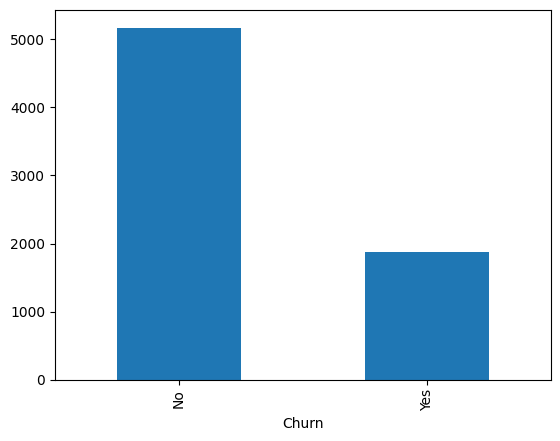

In [19]:
df["Churn"].value_counts().plot(kind="bar")  #yes or value 
plt.show()

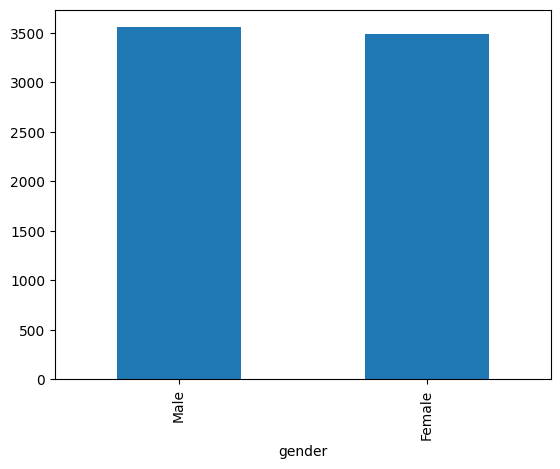

In [20]:
df["gender"].value_counts().plot(kind="bar")
plt.show()

**- Gender distribution is balanced**

**Data Cleaning**

In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df = df.drop('customerID', axis=1)

**Split X and Y**

In [22]:
X = df.drop('Churn', axis=1)
y = df['Churn']

**Feature Engineering**

In [23]:
X = pd.get_dummies(X, drop_first=True)
y = y.map({'Yes': 1, 'No': 0})

**Train-Test-Split**

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Model**

In [25]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [26]:
rf_pred = rf_model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, rf_pred)
print(rf_accuracy)

0.7882018479033405


**Compare Models**


****Logistic Regression: 0.787% ,, Random Forest: 0.788%****
